📚 Downloading Wikitext-2 corpus...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

✅ Corpus saved with 23767 lines.

🚀 Training BPE Tokenizers (This will take a few minutes)...
Training 8K vocabulary...
Training 16K vocabulary...
Training 32K vocabulary...
Training 64K vocabulary...
Training 128K vocabulary...
Training 256K vocabulary...


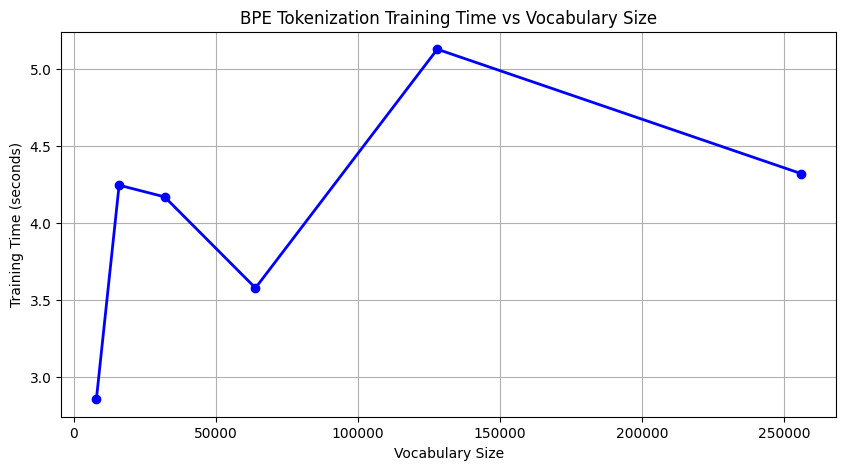


🎉 DONE! All 6 tokenizers are trained and saved to your Colab files.


In [1]:
# --- 1. INSTALL LIBRARIES ---
!pip install datasets tokenizers matplotlib psutil -q

import time
import os
import psutil
import matplotlib.pyplot as plt
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# --- 2. GET THE CORPUS ---
print("📚 Downloading Wikitext-2 corpus...")
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
# Filter out empty lines to make training cleaner
corpus = [line for line in dataset['text'] if line.strip() != ""]

# Save corpus to a local text file for the tokenizer to read
corpus_path = "corpus.txt"
with open(corpus_path, "w", encoding="utf-8") as f:
    for line in corpus:
        f.write(line + "\n")
print(f"✅ Corpus saved with {len(corpus)} lines.")

# --- 3. TRAIN BPE TOKENIZERS ---
vocab_sizes = [8000, 16000, 32000, 64000, 128000, 256000]
results = {}

print("\n🚀 Training BPE Tokenizers (This will take a few minutes)...")
for size in vocab_sizes:
    print(f"Training {size//1000}K vocabulary...")

    # Track Memory & Time
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss
    start_time = time.time()

    # Initialize BPE
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()

    # Setup Trainer
    trainer = BpeTrainer(special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"], vocab_size=size)

    # Train
    tokenizer.train(files=[corpus_path], trainer=trainer)

    # Calculate Time & Memory
    train_time = time.time() - start_time
    mem_after = process.memory_info().rss
    memory_used_mb = (mem_after - mem_before) / (1024 * 1024)

    # Save the files for your deliverables!
    save_path = f"bpe_tokenizer_{size//1000}k.json"
    tokenizer.save(save_path)

    # Store metrics
    results[size] = {
        "time": train_time,
        "memory_mb": max(0, memory_used_mb), # Ensure no negative readings
        "file": save_path
    }

# --- 4. PLOT PERFORMANCE METRICS ---
sizes = list(results.keys())
times = [results[s]["time"] for s in sizes]

plt.figure(figsize=(10, 5))
plt.plot(sizes, times, marker='o', color='b', linewidth=2)
plt.title('BPE Tokenization Training Time vs Vocabulary Size')
plt.xlabel('Vocabulary Size')
plt.ylabel('Training Time (seconds)')
plt.grid(True)
plt.show()

print("\n🎉 DONE! All 6 tokenizers are trained and saved to your Colab files.")

In [2]:
import pandas as pd
from tokenizers import Tokenizer

# We will test the tokenizers on a sample paragraph with some tricky words
test_text = """
The quick brown fox jumps over the lazy dog.
Tokenization is essential for large language models!
Let's test out-of-vocabulary words like supercalifragilisticexpialidocious and neologisms.
"""

# Count the base words and characters
num_words = len(test_text.split())
num_chars = len(test_text)

results_eval = []
vocab_sizes = [8000, 16000, 32000, 64000, 128000, 256000]

print("📊 Evaluating Tokenizer Performance...\n")

for size in vocab_sizes:
    # Load the saved file
    tok = Tokenizer.from_file(f"bpe_tokenizer_{size//1000}k.json")

    # Encode the text
    encoded = tok.encode(test_text)
    tokens = encoded.tokens
    num_tokens = len(tokens)

    # Calculate metrics
    unk_count = tokens.count("[UNK]")
    oov_rate = (unk_count / num_tokens) * 100 if num_tokens > 0 else 0
    avg_tokens = num_tokens / num_words if num_words > 0 else 0
    compression_ratio = num_chars / num_tokens if num_tokens > 0 else 0

    results_eval.append({
        "Vocab Size": f"{size//1000}K",
        "Total Tokens": num_tokens,
        "Tokens/Word": round(avg_tokens, 2),
        "Compression Ratio": round(compression_ratio, 2),
        "OOV Rate (%)": round(oov_rate, 2)
    })

# Display as a beautiful table
df = pd.DataFrame(results_eval)
print(df.to_string(index=False))

# Visualize some learned subwords from the 8K model
print("\n🔍 Sample of Learned Subwords (8K Vocab):")
tok_8k = Tokenizer.from_file("bpe_tokenizer_8k.json")
vocab_dict = tok_8k.get_vocab()
# Sort by ID to see the first learned merges (skipping the single characters)
sorted_vocab = sorted(vocab_dict.items(), key=lambda x: x[1])
print([word for word, idx in sorted_vocab[300:320]])

📊 Evaluating Tokenizer Performance...

Vocab Size  Total Tokens  Tokens/Word  Compression Ratio  OOV Rate (%)
        8K            57         2.38               3.37           0.0
       16K            52         2.17               3.69           0.0
       32K            50         2.08               3.84           0.0
       64K            46         1.92               4.17           0.0
      128K            44         1.83               4.36           0.0
      256K            44         1.83               4.36           0.0

🔍 Sample of Learned Subwords (8K Vocab):
['г', 'д', 'е', 'ж', 'з', 'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'х', 'ц', 'ш']
